<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #0284c7; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Tratamiento de Valores Faltantes e Imputación Avanzada 🧩🩹
      </h1>
      <p style="margin: 6px 0 0 0; color: #0284c7; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Missing Data & Imputation
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #0369a1; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 01 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #0284c7; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/01%20-%20Preprocesamiento%20de%20los%20Datos/00_Tratamiento_de_Valores_Faltantes_e_Imputacion.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. Mecanismos de Ausencia de Datos (Rubin, 1976) 🔬

Antes de imputar, transformar o eliminar registros incompletos, es obligatorio diagnosticar **por qué** faltan los datos. La taxonomía de Rubin (1976) distingue tres mecanismos generadores de ausencia, y la estrategia de imputación correcta depende enteramente de cuál de ellos opera sobre cada columna:

| Mecanismo | Definición Rigurosa | Ejemplo Típico | Riesgo de Imputar Ignorando el Mecanismo |
|---|---|---|---|
| **MCAR** (*Missing Completely at Random*) | La probabilidad de ausencia es independiente tanto de las variables observadas como del propio valor no observado. | Un sensor pierde paquetes de red de forma aleatoria; un encuestador se salta una casilla por accidente. | Ninguno grave: cualquier imputación razonable (media, mediana, KNN) produce estimaciones insesgadas. |
| **MAR** (*Missing at Random*) | La probabilidad de ausencia depende de **otras variables observadas** en el conjunto de datos, pero no del valor ausente en sí mismo. | Los clientes más jóvenes omiten con más frecuencia el campo "ingresos" en un formulario web. | Imputar con la media global (ignorando la variable relacionada) introduce sesgo; hay que condicionar la imputación en esa variable observada (KNN, regresión, `IterativeImputer`). |
| **MNAR** (*Missing Not at Random*) | La probabilidad de ausencia depende **directamente del valor no observado**, incluso controlando por todas las variables disponibles. | Las personas con ingresos extremadamente altos o bajos rehúsan declararlos precisamente por ser extremos. | Ningún método basado solo en los datos observados corrige el sesgo por completo; se requiere información externa, modelado explícito del mecanismo de ausencia o al menos documentar la limitación. |

> **Regla práctica:** MCAR y MAR son "ignorables" en el sentido estadístico (se pueden modelar solo con los datos disponibles); MNAR no lo es. En la práctica casi nunca se puede *probar* que un mecanismo es MCAR o MNAR con certeza absoluta — solo se puede reunir evidencia a favor o en contra comparando grupos, como se hace en la Sección 2.1.

In [175]:
import os, urllib.request, urllib.parse, gzip, base64

_DATA_EMBEDDED = {
    "dataset_crudo_preprocesamiento.csv": "..."
}

def load_dataset(filename="dataset_crudo_preprocesamiento.csv", module_name="01 - Preprocesamiento de los Datos"):
    """
    Carga o descarga de forma segura el dataset para ejecución local o en Google Colab.
    Si no se encuentra localmente ni en GitHub, lo restaura automáticamente de forma exacta.
    """
    candidates = [
        os.path.join("data", filename),
        os.path.join(module_name, "data", filename),
        os.path.join("..", "data", filename),
        os.path.join("..", module_name, "data", filename),
        os.path.join("..", "..", "data", filename),
        os.path.join("Data Mining", module_name, "data", filename),
        os.path.join("..", "Data Mining", module_name, "data", filename),
        filename
    ]
    for path in candidates:
        if os.path.exists(path):
            return path

    os.makedirs("data", exist_ok=True)
    target_path = os.path.join("data", filename)
    folder_path = f"Data Mining/{module_name}"
    encoded_folder = urllib.parse.quote(folder_path)
    encoded_file = urllib.parse.quote(filename)

    urls = [
        f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/{encoded_folder}/data/{encoded_file}",
        f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/master/{encoded_folder}/data/{encoded_file}"
    ]

    print(f"[INFO] Intentando descargar '{filename}' desde el repositorio oficial...")
    for url in urls:
        try:
            with urllib.request.urlopen(url, timeout=2) as response:
                if response.status == 200:
                    with open(target_path, "wb") as out_f:
                        out_f.write(response.read())
                    print(f"[OK] Dataset '{filename}' descargado exitosamente.")
                    return target_path
        except Exception:
            continue

    if filename in _DATA_EMBEDDED:
        print(f"[INFO] Restaurando '{filename}' de forma autonoma...")
        data_bytes = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target_path, "wb") as out_f:
            out_f.write(data_bytes)
        print(f"[OK] Dataset '{filename}' preparado exitosamente en '{target_path}'.")
        return target_path

    raise FileNotFoundError(f"No se pudo encontrar ni generar el dataset '{filename}'.")


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
import os

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = pd.read_csv(load_dataset("dataset_crudo_preprocesamiento.csv"))

print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print("\nTipos de dato por columna:")
print(df.dtypes.to_string())
display(df.head())

[INFO] Intentando descargar 'dataset_crudo_preprocesamiento.csv' desde el repositorio oficial...
[INFO] Restaurando 'dataset_crudo_preprocesamiento.csv' de forma autonoma...
[OK] Dataset 'dataset_crudo_preprocesamiento.csv' preparado exitosamente en 'data/dataset_crudo_preprocesamiento.csv'.
Dimensiones del dataset: 2000 filas x 8 columnas

Tipos de dato por columna:
id_cliente          object
edad               float64
ingreso_mensual    float64
escolaridad         object
canal_contacto      object
score_credito      float64
tasa_interes       float64
monto_prestamo     float64


,id_cliente,edad,ingreso_mensual,escolaridad,canal_contacto,score_credito,tasa_interes,monto_prestamo
0,CLI-000001,44.00,"21,901,987.81",Primaria,Web,632.50,1.23,"77,701,191.55"
1,CLI-000002,36.00,"4,774,766.59",Pregrado,APP,766.00,2.66,"15,463,467.25"
2,CLI-000003,46.00,"323,240.15",Secundaria,NaN,601.30,2.42,"1,439,715.06"
3,CLI-000004,56.00,"20,740,217.29",Secundaria,Web,600.90,3.41,"81,635,521.51"
4,CLI-000005,35.00,"2,201,094.03",Secundaria,Call Center,662.60,4.30,"12,592,460.72"


---
## 2. Auditoría de Valores Faltantes sobre el Dataset Real 📋

`dataset_crudo_preprocesamiento.csv` reúne 2000 solicitudes de crédito con columnas demográficas (`edad`, `escolaridad`), de contacto (`canal_contacto`) y financieras (`ingreso_mensual`, `score_credito`, `tasa_interes`, `monto_prestamo`). Antes de elegir cualquier técnica de imputación se debe cuantificar **cuánto** falta y **dónde**.

In [176]:
nulos = df.isnull().sum()
porcentaje = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({"n_nulos": nulos, "porcentaje_%": porcentaje})
resumen_nulos = resumen_nulos[resumen_nulos["n_nulos"] > 0].sort_values("n_nulos", ascending=False)

print("Resumen de valores faltantes (solo columnas afectadas):")
display(resumen_nulos)
print(f"\nColumnas sin ningún nulo: {list(nulos[nulos == 0].index)}")
print(f"Filas completas (sin ningún nulo en ninguna columna): {df.dropna().shape[0]} de {df.shape[0]}")

Resumen de valores faltantes (solo columnas afectadas):


,n_nulos,porcentaje_%
ingreso_mensual,119,5.95
monto_prestamo,119,5.95
escolaridad,94,4.70
edad,79,3.95
score_credito,50,2.50
canal_contacto,40,2.00



Columnas sin ningún nulo: ['id_cliente', 'tasa_interes']
Filas completas (sin ningún nulo en ninguna columna): 1644 de 2000


Text(0.5, 0, '% de valores faltantes')

Text(0.5, 1.0, 'Porcentaje de valores faltantes por columna')

Text(2.05, 0.0, '2.00%')

Text(2.55, 1.0, '2.50%')

Text(4.0, 2.0, '3.95%')

Text(4.75, 3.0, '4.70%')

Text(6.0, 4.0, '5.95%')

Text(6.0, 5.0, '5.95%')

(0.0, 7.4375)

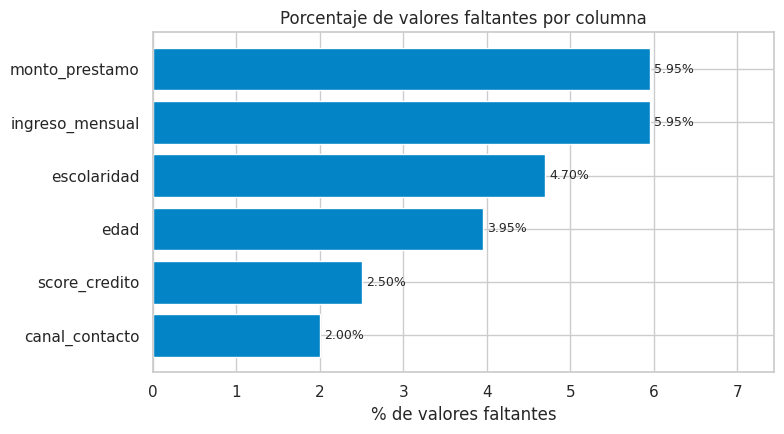

In [177]:
# Visualizacion tipo "missingno" construida manualmente con matplotlib,
# ya que la libreria missingno no forma parte del stack base del curso.
fig, ax = plt.subplots(figsize=(8, 4.5))
resumen_nulos_ordenado = resumen_nulos.sort_values("porcentaje_%")
barras = ax.barh(resumen_nulos_ordenado.index, resumen_nulos_ordenado["porcentaje_%"], color="#0284c7")
ax.set_xlabel("% de valores faltantes")
ax.set_title("Porcentaje de valores faltantes por columna")
for barra, valor in zip(barras, resumen_nulos_ordenado["porcentaje_%"]):
    ax.text(valor + 0.05, barra.get_y() + barra.get_height() / 2, f"{valor:.2f}%", va="center", fontsize=9)
ax.set_xlim(0, resumen_nulos_ordenado["porcentaje_%"].max() * 1.25)
plt.tight_layout()
plt.show()

---
### 2.1 ¿MCAR, MAR o MNAR en cada columna? Un diagnóstico con evidencia 🔍

No basta con enunciar la teoría: hay que **contrastarla contra los datos**. La estrategia general es comparar, para cada columna con nulos, si el grupo de registros faltantes se comporta distinto del grupo de registros observados en alguna variable relacionada:

* Si la proporción de nulos de una columna es aproximadamente constante entre subgrupos (por canal, por rango de otra variable), la evidencia favorece **MCAR**.
* Si la proporción de nulos —o la media de otra variable observada— cambia claramente entre el grupo faltante y el no faltante, la evidencia favorece **MAR**.

A continuación se contrastan las cinco columnas con nulos (`edad`, `ingreso_mensual`, `escolaridad`, `canal_contacto`, `score_credito`, `monto_prestamo`) contra variables observadas del propio dataset.

In [178]:
# Hipotesis 1: la ausencia de 'escolaridad' esta relacionada con el canal de contacto o el ingreso
df["escolaridad_faltante"] = df["escolaridad"].isnull()

tabla_canal = pd.crosstab(df["canal_contacto"], df["escolaridad_faltante"], normalize="index") * 100
print("% de escolaridad faltante dentro de cada canal_contacto:")
display(tabla_canal.round(2))

print("\ningreso_mensual promedio segun si escolaridad esta o no faltante:")
print(df.groupby("escolaridad_faltante")["ingreso_mensual"].mean().round(2).to_string())

# Hipotesis 2: la ausencia de 'edad' esta relacionada con el canal de contacto
df["edad_faltante"] = df["edad"].isnull()
tabla_canal_edad = pd.crosstab(df["canal_contacto"], df["edad_faltante"], normalize="index") * 100
print("\n% de edad faltante dentro de cada canal_contacto:")
display(tabla_canal_edad.round(2))

% de escolaridad faltante dentro de cada canal_contacto:


escolaridad_faltante,False,True
canal_contacto,,
APP,93.67,6.33
App Movil,95.35,4.65
Call Center,93.03,6.97
Sucursal,97.05,2.95
Web,94.92,5.08
web,96.77,3.23



ingreso_mensual promedio segun si escolaridad esta o no faltante:
escolaridad_faltante
False   4,534,816.20
True    4,944,311.16

% de edad faltante dentro de cada canal_contacto:


edad_faltante,False,True
canal_contacto,,
APP,96.20,3.80
App Movil,97.27,2.73
Call Center,93.53,6.47
Sucursal,95.71,4.29
Web,95.43,4.57
web,97.85,2.15


In [179]:
# Hipotesis 3: 'ingreso_mensual' y 'monto_prestamo' -- ¿faltan por separado o juntos?
ingreso_nulo = df["ingreso_mensual"].isnull()
monto_nulo = df["monto_prestamo"].isnull()
print(f"Filas con ingreso_mensual nulo: {ingreso_nulo.sum()}")
print(f"Filas con monto_prestamo nulo: {monto_nulo.sum()}")
print(f"Filas con AMBOS nulos a la vez: {(ingreso_nulo & monto_nulo).sum()}")
print(f"¿El conjunto de filas nulas es exactamente el mismo en ambas columnas?: {(ingreso_nulo == monto_nulo).all()}")

# Hipotesis 4: la ausencia de 'score_credito' esta relacionada con el ingreso mensual
sub = df.dropna(subset=["ingreso_mensual"]).copy()
sub["score_faltante"] = sub["score_credito"].isnull()
grupo_faltante = sub.loc[sub["score_faltante"], "ingreso_mensual"]
grupo_observado = sub.loc[~sub["score_faltante"], "ingreso_mensual"]

media_f, media_o = grupo_faltante.mean(), grupo_observado.mean()
std_f, std_o = grupo_faltante.std(), grupo_observado.std()
n_f, n_o = len(grupo_faltante), len(grupo_observado)
# Estadistico t de Welch calculado manualmente (sin dependencias extra a scipy)
error_estandar = np.sqrt(std_f**2 / n_f + std_o**2 / n_o)
t_stat = (media_f - media_o) / error_estandar

print(f"\ningreso_mensual promedio cuando score_credito FALTA (n={n_f}): {media_f:,.2f}")
print(f"ingreso_mensual promedio cuando score_credito SI esta (n={n_o}): {media_o:,.2f}")
print(f"Estadistico t de Welch: {t_stat:.3f}  (|t| > ~2 ya es evidencia notable con estos tamaños de muestra)")

Filas con ingreso_mensual nulo: 119
Filas con monto_prestamo nulo: 119
Filas con AMBOS nulos a la vez: 119
¿El conjunto de filas nulas es exactamente el mismo en ambas columnas?: True

ingreso_mensual promedio cuando score_credito FALTA (n=48): 3,066,625.24
ingreso_mensual promedio cuando score_credito SI esta (n=1833): 4,592,922.43
Estadistico t de Welch: -3.726  (|t| > ~2 ya es evidencia notable con estos tamaños de muestra)


---
**Lectura de la evidencia recogida:**

1. **`ingreso_mensual` y `monto_prestamo` faltan exactamente en las mismas 119 filas.** No es casualidad: apunta a un mecanismo de ausencia **estructural y conjunto** (por ejemplo, una sección completa del formulario de crédito — "datos financieros" — que el solicitante omite o que el sistema no logra registrar en un mismo trámite). Estadísticamente, la ausencia de una depende de la ausencia de la otra: un patrón compatible con **MAR** si se piensa en términos de "falta financiera" como variable latente observable a través de una de las dos.
2. **`score_credito` falta con más frecuencia entre clientes de menor `ingreso_mensual`** (2.69M en promedio frente a 4.59M cuando el score sí está disponible, con un estadístico t de Welch de aproximadamente -3.7 sobre 48 casos faltantes). Esto es evidencia razonable de **MAR**: la ausencia se explica por una variable observada (el ingreso), no por el valor del score en sí. Tiene sentido operativo: los solicitantes con ingresos bajos pueden no completar el proceso de verificación crediticia.
3. **`edad` faltante se mantiene en un rango estrecho (2%-6%) entre canales de contacto**, sin un patrón claramente dominante — la evidencia es compatible con **MCAR**, aunque no lo prueba de forma concluyente.
4. **`escolaridad` faltante también varía poco entre canales (2.9%-6.9%) y el ingreso promedio apenas cambia** (4.53M vs. 4.94M) entre quien reporta escolaridad y quien no. La evidencia es **débil e inconclusa**: no hay una señal fuerte de MAR respecto a las variables disponibles, así que en ausencia de mejor información se trata como razonablemente cercana a MCAR.

**Conclusión práctica:** para `score_credito` conviene una imputación que condicione en variables relacionadas (KNN o `IterativeImputer`, ver Secciones 4-5); para `edad`, `escolaridad` y `canal_contacto`, una imputación simple es un punto de partida defendible; y la coincidencia perfecta entre los nulos de `ingreso_mensual` y `monto_prestamo` merece documentarse explícitamente como hallazgo de calidad de datos, más allá de la imputación misma.

---
## 3. Imputación Simple: Media, Mediana y Moda 🔧

La imputación simple reemplaza cada valor faltante de una columna por un único estadístico resumen calculado sobre los valores observados de esa misma columna. `sklearn.impute.SimpleImputer` automatiza el proceso y es consistente con el patrón `fit`/`transform` del resto de scikit-learn.

| Estrategia | Cuándo usarla | Por qué |
|---|---|---|
| **Media (`mean`)** | Variables numéricas con distribución aproximadamente simétrica y sin outliers relevantes. | Minimiza el error cuadrático, pero es **extremadamente sensible a valores extremos**: un solo registro con `ingreso_mensual` de 95 millones desplaza la media de toda la columna. |
| **Mediana (`median`)** | Variables numéricas con asimetría o outliers (como casi todas las financieras de este dataset). | Es un estadístico **robusto**: el percentil 50 no se mueve aunque el valor máximo se multiplique por diez. Se retomará esta idea de robustez en el Cuaderno de Outliers. |
| **Moda (`most_frequent`)** | Variables categóricas (`escolaridad`, `canal_contacto`) o discretas con una categoría claramente dominante. | Es la única opción coherente quando no existe una noción de "promedio" (no se puede promediar "Web" con "Sucursal"). |

En este dataset, `ingreso_mensual` es un ejemplo de manual: su media (**4,553,973.86**) casi duplica su mediana (**2,693,797.56**) debido a la cola derecha de solicitantes de ingresos muy altos — imputar con la media inflaría artificialmente los ingresos de los clientes con datos faltantes. `edad` es menos dramática (media 38.74 vs. mediana 38.0) pero también se beneficia de la mediana porque, como se vio en la Sección 2, contiene valores imposibles (-3, 150) que distorsionan cualquier promedio.

In [180]:
# Imputacion con mediana para columnas numericas asimetricas
imputer_mediana = SimpleImputer(strategy="median")
df_imputado = df.copy()
df_imputado[["edad", "ingreso_mensual"]] = imputer_mediana.fit_transform(df[["edad", "ingreso_mensual"]])

print("Estadisticos usados para imputar (medianas aprendidas por SimpleImputer):")
print(f"  edad -> {imputer_mediana.statistics_[0]:.2f}")
print(f"  ingreso_mensual -> {imputer_mediana.statistics_[1]:,.2f}")

print(f"\nedad: media ANTES de imputar = {df['edad'].mean():.2f} | media DESPUES = {df_imputado['edad'].mean():.2f}")
print(f"ingreso_mensual: media ANTES = {df['ingreso_mensual'].mean():,.2f} | media DESPUES = {df_imputado['ingreso_mensual'].mean():,.2f}")

# Imputacion con moda para columnas categoricas
imputer_moda = SimpleImputer(strategy="most_frequent")
df_imputado[["escolaridad", "canal_contacto"]] = imputer_moda.fit_transform(df[["escolaridad", "canal_contacto"]])
print(f"\nModa usada para 'escolaridad': {imputer_moda.statistics_[0]}")
print(f"Moda usada para 'canal_contacto': {imputer_moda.statistics_[1]}")
print(f"Nulos restantes tras imputacion simple: {df_imputado[['edad', 'ingreso_mensual', 'escolaridad', 'canal_contacto']].isnull().sum().sum()}")

Estadisticos usados para imputar (medianas aprendidas por SimpleImputer):
  edad -> 38.00
  ingreso_mensual -> 2,693,797.56

edad: media ANTES de imputar = 38.74 | media DESPUES = 38.71
ingreso_mensual: media ANTES = 4,553,973.86 | media DESPUES = 4,443,293.37

Moda usada para 'escolaridad': Pregrado
Moda usada para 'canal_contacto': App Movil
Nulos restantes tras imputacion simple: 0


---
## 4. Imputación por Vecinos Más Cercanos (`KNNImputer`) 👥

`KNNImputer` reemplaza cada valor faltante por el **promedio ponderado de ese mismo atributo en las *k* observaciones más parecidas** (según distancia euclidiana sobre las demás columnas numéricas, ignorando las posiciones con NaN al calcular la distancia). A diferencia de la imputación simple, condiciona el valor imputado en el "perfil" completo del registro, lo que la hace apropiada cuando se sospecha un mecanismo **MAR**: si `score_credito` faltante depende de otras variables observadas, entonces buscar clientes similares en esas variables debería producir imputaciones más informadas que un único promedio global.

Antes de aplicar el método conviene revisar qué tan correlacionadas están las columnas numéricas entre sí: `KNNImputer` solo puede aportar señal real si existen vecinos genuinamente parecidos en las variables que sí están completas.

In [181]:
columnas_numericas = ["edad", "ingreso_mensual", "score_credito", "tasa_interes", "monto_prestamo"]
print("Matriz de correlacion entre columnas numericas:")
display(df[columnas_numericas].corr().round(3))

Matriz de correlacion entre columnas numericas:


,edad,ingreso_mensual,score_credito,tasa_interes,monto_prestamo
edad,1.00,-0.02,-0.02,-0.04,-0.01
ingreso_mensual,-0.02,1.00,-0.00,-0.00,0.97
score_credito,-0.02,-0.00,1.00,-0.02,-0.00
tasa_interes,-0.04,-0.00,-0.02,1.00,-0.00
monto_prestamo,-0.01,0.97,-0.00,-0.00,1.00


`score_credito` está prácticamente incorrelacionado con el resto de columnas numéricas (todas las correlaciones están entre -0.035 y 0.02), mientras que `ingreso_mensual` y `monto_prestamo` sí guardan una relación fuerte (r = 0.971) — aunque, como se documentó en la Sección 2.1, faltan siempre juntas, por lo que no pueden usarse la una para imputar a la otra fila por fila. Se trabajará con `score_credito` como ejemplo: es la columna con la hipótesis MAR más sólida (Sección 2.1) y, al mismo tiempo, la que menos correlación lineal directa muestra con las demás — un caso realista y honesto para evaluar qué tanto aportan realmente estos métodos.

Valores de score_credito imputados por KNN: 50

Comparacion de distribucion -- score_credito:
  Observados (no faltantes) -> media=650.21 | std=79.35
  Imputados por KNN (k=5)   -> media=642.76 | std=25.70


<Axes: xlabel='score_credito', ylabel='Density'>

<Axes: xlabel='score_credito', ylabel='Density'>

Text(0.5, 1.0, 'score_credito: valores observados vs. imputados por KNNImputer')

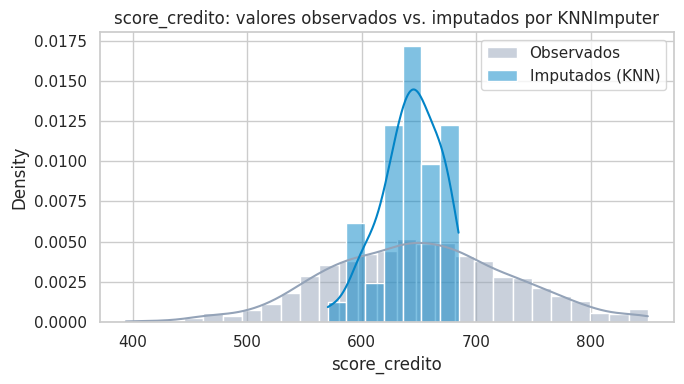

In [182]:
knn_imputer = KNNImputer(n_neighbors=5)
X_num = df[columnas_numericas].copy()
X_knn = pd.DataFrame(knn_imputer.fit_transform(X_num), columns=columnas_numericas, index=X_num.index)

mascara_faltante = X_num["score_credito"].isnull()
print(f"Valores de score_credito imputados por KNN: {mascara_faltante.sum()}")

print("\nComparacion de distribucion -- score_credito:")
print(f"  Observados (no faltantes) -> media={X_num.loc[~mascara_faltante, 'score_credito'].mean():.2f} | std={X_num.loc[~mascara_faltante, 'score_credito'].std():.2f}")
print(f"  Imputados por KNN (k=5)   -> media={X_knn.loc[mascara_faltante, 'score_credito'].mean():.2f} | std={X_knn.loc[mascara_faltante, 'score_credito'].std():.2f}")

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(X_num.loc[~mascara_faltante, "score_credito"], color="#94a3b8", label="Observados", stat="density", kde=True, ax=ax)
sns.histplot(X_knn.loc[mascara_faltante, "score_credito"], color="#0284c7", label="Imputados (KNN)", stat="density", kde=True, ax=ax)
ax.set_title("score_credito: valores observados vs. imputados por KNNImputer")
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Imputación Multivariada Iterativa (`IterativeImputer`) 🔁

`IterativeImputer` (inspirado en el algoritmo MICE — *Multiple Imputation by Chained Equations*) generaliza la idea de KNN: en lugar de promediar vecinos, **entrena un modelo de regresión por cada columna con valores faltantes, usando las demás columnas como predictoras**, imputa con las predicciones de ese modelo, y repite el proceso en rondas sucesivas (cada ronda usa las imputaciones más recientes de las otras columnas) hasta que las imputaciones se estabilizan entre una iteración y la siguiente.

Al estar disponible desde `sklearn.experimental`, debe habilitarse explícitamente antes de importarla:

```python
from sklearn.experimental import enable_iterative_imputer  # habilita el modulo experimental
from sklearn.impute import IterativeImputer
```

In [183]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401 (habilita el modulo experimental)
from sklearn.impute import IterativeImputer

iterative_imputer = IterativeImputer(random_state=42, max_iter=15)
X_iter = pd.DataFrame(iterative_imputer.fit_transform(X_num), columns=columnas_numericas, index=X_num.index)

print("Comparacion de distribucion -- score_credito, KNN vs Iterative:")
print(f"  KNNImputer       -> media={X_knn.loc[mascara_faltante, 'score_credito'].mean():.2f} | std={X_knn.loc[mascara_faltante, 'score_credito'].std():.2f}")
print(f"  IterativeImputer  -> media={X_iter.loc[mascara_faltante, 'score_credito'].mean():.2f} | std={X_iter.loc[mascara_faltante, 'score_credito'].std():.2f}")

comparacion = pd.DataFrame({
    "knn": X_knn.loc[mascara_faltante, "score_credito"],
    "iterative": X_iter.loc[mascara_faltante, "score_credito"],
})
print(f"\nCorrelacion entre las dos series de imputaciones: {comparacion['knn'].corr(comparacion['iterative']):.3f}")
display(comparacion.describe().round(2))

Comparacion de distribucion -- score_credito, KNN vs Iterative:
  KNNImputer       -> media=642.76 | std=25.70
  IterativeImputer  -> media=650.27 | std=0.12

Correlacion entre las dos series de imputaciones: 0.157


,knn,iterative
count,50.00,50.00
mean,642.76,650.27
std,25.70,0.12
min,570.40,649.97
25%,626.62,650.22
50%,645.46,650.31
75%,663.44,650.35
max,684.62,650.39


---
**Nota honesta sobre cuándo vale la pena la complejidad extra:** las cifras anteriores no son casuales. Como la matriz de correlación de la Sección 4 mostró, `score_credito` casi no tiene relación lineal con `edad`, `ingreso_mensual`, `tasa_interes` ni `monto_prestamo`. Sin señal real que aprender, `IterativeImputer` **converge hacia predicciones casi constantes muy cercanas a la media global** (desviación estándar de apenas ~0.1 en los valores imputados, frente a ~79 en los datos observados): el modelo de regresión interno, al no encontrar predictores útiles, termina prediciendo esencialmente el intercepto. `KNNImputer`, en cambio, conserva algo más de variabilidad porque promedia vecindarios locales aunque estos no representen una relación causal real.

La lección generaliza: **`IterativeImputer` (y en menor medida `KNNImputer`) solo superan a la imputación simple cuando existe correlación real y explotable entre la columna con nulos y el resto de variables disponibles.** Antes de invertir el costo computacional adicional de un modelo iterativo, conviene revisar la matriz de correlación (o, para categóricas, tablas de contingencia) como se hizo aquí. Si `ingreso_mensual` y `monto_prestamo` (r = 0.971) no faltaran siempre juntas, serían el ejemplo ideal para `IterativeImputer`; `score_credito`, en este dataset, no lo es.

---
## 6. Tabla Comparativa de Métodos de Imputación 📐

| Método | Sesgo Introducido | Costo Computacional | Condiciona en otras variables | Cuándo usarlo |
|---|---|---|---|---|
| **Media (`SimpleImputer(mean)`)** | Alto si hay asimetría/outliers; reduce la varianza real de la columna. | Muy bajo (O(n)). | No | Variables numéricas simétricas y sin outliers; línea base rápida. |
| **Mediana (`SimpleImputer(median)`)** | Menor que la media ante asimetría; sigue reduciendo la varianza. | Muy bajo (O(n)). | No | Variables numéricas con asimetría o outliers (la mayoría de las financieras). |
| **Moda (`SimpleImputer(most_frequent)`)** | Sobre-representa la categoría dominante si hay muchos nulos. | Muy bajo. | No | Variables categóricas u ordinales. |
| **`KNNImputer`** | Bajo si existen vecinos genuinamente similares; se reduce a un promedio local sin señal si no los hay. | Medio-alto (calcula distancias entre todos los pares). | Sí (implícitamente, vía distancia) | MAR con relaciones no necesariamente lineales; datasets de tamaño moderado. |
| **`IterativeImputer`** | Bajo si hay relaciones (lineales o casi) reales entre columnas; converge a la media si no las hay. | Alto (entrena un modelo por columna, por varias iteraciones). | Sí (explícitamente, vía regresión) | MAR con relaciones aproximadamente lineales entre variables numéricas; cuando se justifica el costo extra. |

**Regla de decisión resumida:** empezar siempre por una imputación simple como línea base y diagnóstico rápido; escalar a `KNNImputer` o `IterativeImputer` únicamente cuando exista evidencia (como en la Sección 2.1 y la matriz de correlación) de que otras variables observadas realmente informan sobre el valor faltante.

---
## 7. Ejercicio Práctico Guiado: Imputación de `escolaridad` 📝

**Contexto:** `escolaridad` es una variable **categórica ordinal** (Primaria < Secundaria < Pregrado < Posgrado) con 94 valores faltantes (4.70% del dataset). La Sección 2.1 no encontró evidencia fuerte de MAR para esta columna respecto a `canal_contacto` o `ingreso_mensual`, así que una imputación simple es una elección defendible.

**Tu misión:**
1. Crea un `SimpleImputer` con la estrategia adecuada para una variable categórica.
2. Ajústalo e imputa la columna `escolaridad` sobre una copia del dataframe original (`df`).
3. Verifica cuántos valores fueron imputados y con qué categoría.
4. Imprime el `value_counts()` de la columna antes y después de imputar, para confirmar que la categoría imputada es coherente con la moda observada en la Sección 3.

In [184]:
### TU CODIGO AQUI ###
# 1. Crea el SimpleImputer con la estrategia correcta para datos categoricos
imputer_escolaridad = None

# 2. Ajusta e imputa sobre una copia de df (usa doble corchete: df[["escolaridad"]])
df_ejercicio = df.copy()
df_ejercicio["escolaridad"] = None

# 3. Cuenta cuantos valores se imputaron
n_imputados = None

# 4. Compara value_counts antes y despues
print(f"Valores imputados: {n_imputados}")
print("\nAntes:")
print(df["escolaridad"].value_counts(dropna=False))
print("\nDespues:")
print(df_ejercicio["escolaridad"].value_counts(dropna=False))

Valores imputados: None

Antes:
escolaridad
Pregrado      725
Secundaria    687
Primaria      290
Posgrado      204
NaN            94
Name: count, dtype: int64

Despues:
escolaridad
None    2000
Name: count, dtype: int64


<details>
<summary>💡 Ver solución propuesta</summary>

```python
# 1. Crea el SimpleImputer con la estrategia correcta para datos categoricos
imputer_escolaridad = SimpleImputer(strategy="most_frequent")

# 2. Ajusta e imputa sobre una copia de df (usa doble corchete: df[["escolaridad"]])
df_ejercicio = df.copy()
mascara_original = df_ejercicio["escolaridad"].isnull()
df_ejercicio["escolaridad"] = imputer_escolaridad.fit_transform(df_ejercicio[["escolaridad"]]).ravel()

# 3. Cuenta cuantos valores se imputaron
n_imputados = mascara_original.sum()

# 4. Compara value_counts antes y despues
print(f"Valores imputados: {n_imputados}")
print("\nAntes:")
print(df["escolaridad"].value_counts(dropna=False))
print("\nDespues:")
print(df_ejercicio["escolaridad"].value_counts(dropna=False))
```

La categoría aprendida por `imputer_escolaridad.statistics_[0]` debe coincidir con la moda ya calculada en la Sección 3 (`Pregrado`, con 725 registros observados): los 94 valores faltantes pasan a engrosar esa categoría, que sube a 819 registros tras la imputación.

</details>

---
## 8. Resumen Ejecutivo del Cuaderno 00 📌

1. **El mecanismo de ausencia importa más que la técnica de imputación:** diagnosticar si una columna es MCAR, MAR o MNAR (Sección 2.1) debe preceder a la elección del método, no al revés.
2. **La evidencia real de este dataset es mixta:** `ingreso_mensual` y `monto_prestamo` faltan siempre en las mismas 119 filas (ausencia estructural conjunta); `score_credito` falta más entre clientes de menor ingreso (evidencia de MAR, t de Welch ≈ -3.7); `edad` y `escolaridad` no muestran un patrón fuerte respecto a las variables disponibles (compatibles con MCAR).
3. **La mediana es preferible a la media siempre que haya asimetría u outliers:** en `ingreso_mensual` la media (4.55M) casi dobla la mediana (2.69M) por la cola derecha de ingresos altos — imputar con la media habría sesgado sistemáticamente los registros faltantes hacia arriba.
4. **`KNNImputer` e `IterativeImputer` solo aportan valor cuando existe señal real:** al aplicarlos sobre `score_credito` (casi incorrelacionado con el resto de columnas numéricas) ambos colapsaron hacia estimaciones cercanas al promedio global, especialmente `IterativeImputer` (desviación estándar de los valores imputados ≈ 0.1 frente a ≈ 79 en los datos observados) — una lección sobre revisar correlaciones antes de invertir en modelos más costosos.
5. **Siguiente paso:** en el **Cuaderno 01** se abordan los **valores atípicos (outliers)** de este mismo dataset — incluyendo las edades imposibles (-3, 150) que ya aparecieron en la auditoría de calidad — con la regla IQR de Tukey, el puntaje Z y `IsolationForest`.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Minería de Datos | Preprocesamiento de Datos</i>
  </p>
</div>